In [1]:
from afm_lib.instrument.session import call
from afm_lib.utils.recipe_builder import (
    line_sites, grid_sites, check_sites, preview_sites, write_recipe)

In [ ]:
raw = await call("get_experiment_status")
P0 = (raw["stage_x_m"], raw["stage_y_m"])
print(f"P0 = ({P0[0]*1e3:+.4f}, {P0[1]*1e3:+.4f}) mm")

P0 = (+22.4569, +15.1022) mm
AC Air Topography False []


In [ ]:
raw = await call("get_experiment_status")
P1 = (raw["stage_x_m"], raw["stage_y_m"])
span = ((P1[0]-P0[0])**2 + (P1[1]-P0[1])**2) ** 0.5
print(f"P1 = ({P1[0]*1e3:+.4f}, {P1[1]*1e3:+.4f}) mm")
print(f"span = {span*1e3:.3f} mm")

P1 = (+11.2690, -31.4200) mm
span = 43.999 mm


12 sites, spacing 4.000 mm
  ! closest pair: 4000 um (must exceed STAGE_TOL_M or ensure_stage will skip the move)


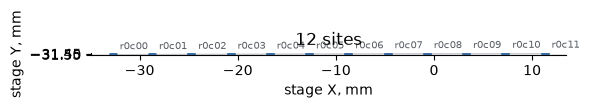

In [15]:
N_SITES = 12

line  = line_sites(P0, P1, N_SITES)
sites = grid_sites(line)                      # single row
print(f"{len(sites)} sites, spacing {span/(N_SITES-1)*1e3:.3f} mm")
for p in check_sites(sites):
    print("  !", p)
preview_sites(sites)

88 sites (8 rows x 11)
  ! closest pair: 4000 um (must exceed STAGE_TOL_M or ensure_stage will skip the move)


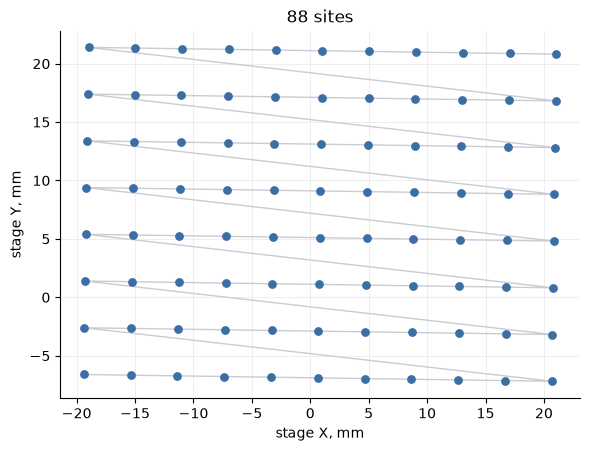

In [16]:
N_ROWS  = 8
ROW_SPACING_M = 4.0e-3          # perpendicular to the P0->P1 line

sites = grid_sites(line, N_ROWS, ROW_SPACING_M)
print(f"{len(sites)} sites ({N_ROWS} rows x {N_SITES})")
for p in check_sites(sites):
    print("  !", p)
preview_sites(sites)

In [16]:
LOOP_SETTINGS = dict(v_dc_max_v=30.0, frequency_hz=0.3, var0_phase=0.0,
                     var1_pulsetime_s=0.05, n_cycles=3)
POINTS_M = [(-1.0e-6, -1.0e-6), (1.0e-6, -1.0e-6),
            (-1.0e-6,  1.0e-6), (1.0e-6,  1.0e-6),
             (0., 2.0e-6), (0., -2.0e-6),
             (-2.0e-6, 0.), (2.0e-6, 0.)]

p = write_recipe("../recipes/pzh_02_AlBN_13%_grid.yaml",
                 name="pzh_02_AlBN_13%_grid",
                 sites=sites,
                 loop_settings=LOOP_SETTINGS,
                 points_m=POINTS_M,
                 context="AlBN 13% B, 200C, 56 min, 250nm"
                        )
print("wrote", p)
print(p.read_text(encoding="utf-8")[:600])

wrote ..\recipes\pzh_02_AlBN_13%_grid.yaml
name: pzh_02_AlBN_13%_grid
context: AlBN 13% B, 200C, 56 min, 250nm
sites:
- label: r0c00
  x_stage_m: -0.032729998
  y_stage_m: -0.031569999
- label: r0c01
  x_stage_m: -0.028730089090909093
  y_stage_m: -0.031556362727272726
- label: r0c02
  x_stage_m: -0.024730180181818183
  y_stage_m: -0.03154272645454546
- label: r0c03
  x_stage_m: -0.020730271272727276
  y_stage_m: -0.03152909018181818
- label: r0c04
  x_stage_m: -0.016730362363636366
  y_stage_m: -0.031515453909090906
- label: r0c05
  x_stage_m: -0.012730453454545456
  y_stage_m: -0.03150181763636364
- label: r0c06
  x_stage_m: -0.00873


In [17]:
from afm_lib.schemas.recipe import load_recipe, site_program

r = load_recipe(p)
n_meas = len(r.sites) * len(site_program(r))
ls = r.per_site[0].loop_settings
per_loop = ls.n_cycles / ls.frequency_hz + 60          # + tune and settle
per_site = 15 + 45                                     # MOVE_WAIT_S + APPROACH_WAIT_S

total = len(r.sites) * per_site + n_meas * per_loop
print(f"{r.name}: {len(r.sites)} sites x {len(site_program(r))} points = {n_meas} loops")
print(f"rough runtime: {total/3600:.1f} h")
print(f"recursion_limit to pass: {20 * n_meas + 100}")

pzh_02_AlBN_13%_grid: 12 sites x 8 points = 96 loops
rough runtime: 2.1 h
recursion_limit to pass: 2020
